In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xso

In [2]:
from phydra.models import NPxZxSizeBased

In [3]:
def calculate_sizes(size_min, size_max, num):
    """initializes log spaced array of sizes from ESD size range"""
    numbers = np.array([i for i in range(num)])
    sizes = (np.log(size_max) - np.log(size_min))* numbers / (num-1) + np.log(size_min)
    return np.exp(sizes)

def calculate_zoo_I0(sizes):
    """initializes allometric Zooplankton ingestion rate based on array of sizes (ESD)"""
    return 26 * sizes ** -0.4

def calculate_phyto_mu0(sizes):
    """initializes allometric Phytoplankton maximum growth rate based on array of sizes (ESD)
    allometric relationships are taken from meta-analyses of lab data"""
    return 2.6 * sizes ** -0.45

def calculate_phyto_ks(sizes):
    """initializes allometric Phytoplankton half-saturation constant based on array of sizes (ESD)"""
    return sizes * .1

def calculate_opt_size(sizes):
    """Calculating optimal prey size from Zooplankton sizes"""
    return 0.65 * sizes ** 0.56


def init_phiP(phytosize, zoopreyoptsize):
    """creates matrix of feeding preferences [P...P10] for each [Z]"""
    phiP = np.array([[np.exp(-((np.log10(xpreyi) - np.log10(xpreyoptj)) / 0.25) ** 2)
                      for xpreyi in phytosize] for xpreyoptj in zoopreyoptsize])
    return phiP

In [38]:
# number size classes of phytoplankton and zooplankotn
PZ_num = 10

# create initial biomass
phyto_init = np.tile(.5/PZ_num, (PZ_num))
zoo_init = np.tile(.1/PZ_num, (PZ_num))

# calculate log-spaced size classes from ranges and total number
phyto_sizes = calculate_sizes(1.,50.,PZ_num)
zoo_sizes = 2.16 * phyto_sizes **1.79 

# ingestion
zoo_I0 = calculate_zoo_I0(zoo_sizes)

# growth
phyto_mu0 = calculate_phyto_mu0(phyto_sizes)
phyto_ks = calculate_phyto_ks(phyto_sizes)

# grazing
preyoptsize = calculate_opt_size(zoo_sizes)
phiP = init_phiP(phyto_sizes, preyoptsize)

In [39]:
phyto_sizes

array([ 1.        ,  1.5444521 ,  2.3853323 ,  3.6840315 ,  5.6898102 ,
        8.78763934, 13.57208808, 20.96144001, 32.37394014, 50.        ])

In [40]:
preyoptsize

array([ 1.0004778 ,  1.54680284,  2.39145638,  3.69734493,  5.71633236,
        8.8378164 , 13.66383091, 21.12515881, 32.66085022, 50.4957689 ])

In [41]:
zoo_sizes

array([2.16000000e+00, 4.70283788e+00, 1.02392056e+01, 2.22932056e+01,
       4.85376535e+01, 1.05678109e+02, 2.30086580e+02, 5.00953651e+02,
       1.09069621e+03, 2.37470714e+03])

In [42]:
BASE_INPUT_VARS={
        # State variables
        'Nutrient':{'value_label':'N','value_init':1.},
        'Phytoplankton':{'biomass_label':'P','biomass_init':phyto_init, 'phyto_index':phyto_sizes},
        'Zooplankton':{'biomass_label':'Z','biomass_init':zoo_init, 'zoo_index': zoo_sizes},
    
        # Flows:
        'Inflow':{'forcing':'N0', 'rate':1., 'var':'N'},
    
        # Growth
        'Growth':{'resource':'N', 'consumer':'P', 'halfsat':phyto_ks, 'mu_max':phyto_mu0},

        # Grazing
        'Grazing':{'resource':'P', 'consumer':'Z',
                   'Imax':zoo_I0, 'KsZ':3., 'phiP':phiP},
        'GGE':{'grazed_resource':'P', 'assimilated_consumer':'Z', 'egested_detritus':'N', 
               'epsilon':1./3., 'f_eg':1./3.},
    
        # Mortality
        'PhytoMortality':{'var':'P', 'rate':0.1*phyto_mu0},
        'ZooMortality':{'var':'Z', 'rate':1.},

        # Forcings
        'N0':{'forcing_label':'N0', 'value':1.},
}

In [43]:
model = NPxZxSizeBased
        
model_setup_stability = xso.setup(
    solver='stability', 
    model=model,
    time=[0,1],
    input_vars=BASE_INPUT_VARS
)

model_setup_ivp = xso.setup(
    solver='solve_ivp', 
    model=model,
    time=np.arange(0,365*10),
    input_vars=BASE_INPUT_VARS
)


/Users/aoop/mambaforge/envs/XSO2025/lib/python3.13/site-packages/xsimlab/xr_accessor.py:229: FutureWarning: variable 'clock' with name matching its dimension will not be automatically converted into an `IndexVariable` object in the future.
  xr_var = as_variable(data, name=dim)


In [44]:
with NPxZxSizeBased:
        model_out = model_setup_ivp.xsimlab.run()

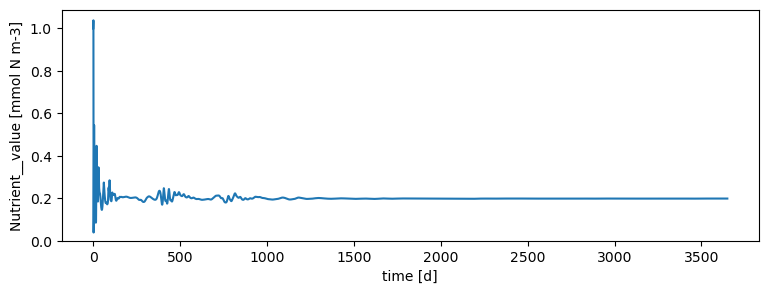

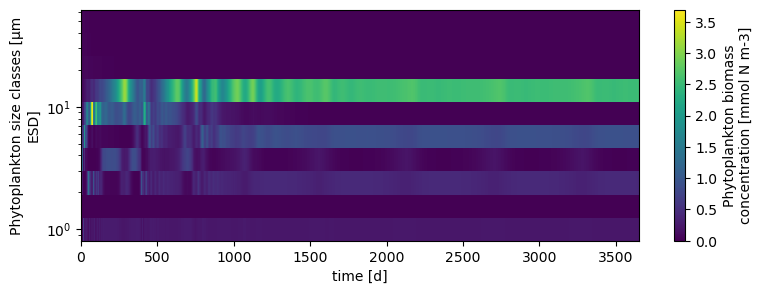

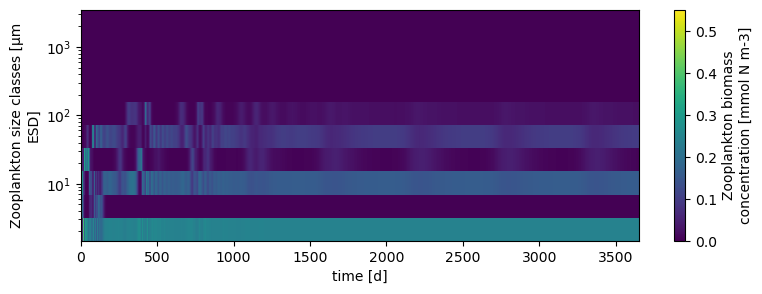

In [45]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [46]:
# Select variables and get the mean of the last 1000 time steps
mean_out = model_out[['Nutrient__value','Phytoplankton__biomass', 'Zooplankton__biomass']] \
                         .isel(time=slice(-1000, None)) \
                         .mean(dim='time')


mean_out

<xarray.Dataset> Size: 328B
Dimensions:                 (phyto: 10, zoo: 10)
Coordinates:
  * phyto                   (phyto) float64 80B 1.0 1.544 2.385 ... 32.37 50.0
  * zoo                     (zoo) float64 80B 2.16 4.703 ... 1.091e+03 2.375e+03
Data variables:
    Nutrient__value         float64 8B 0.1982
    Phytoplankton__biomass  (phyto) float64 80B 0.2293 2.849e-92 ... 4.481e-35
    Zooplankton__biomass    (zoo) float64 80B 0.2434 8.46e-43 0.1531 ... 0.0 0.0

In [47]:
model_setup_ivp_2 = model_setup_ivp.xsimlab.update_vars(model=model,
                             input_vars={'Nutrient__value_init':mean_out.Nutrient__value.values,
                                       'Phytoplankton__biomass_init':mean_out.Phytoplankton__biomass.values,
                                       'Zooplankton__biomass_init':mean_out.Zooplankton__biomass.values})



In [48]:
with NPxZxSizeBased:
        model_out = model_setup_ivp_2.xsimlab.run()

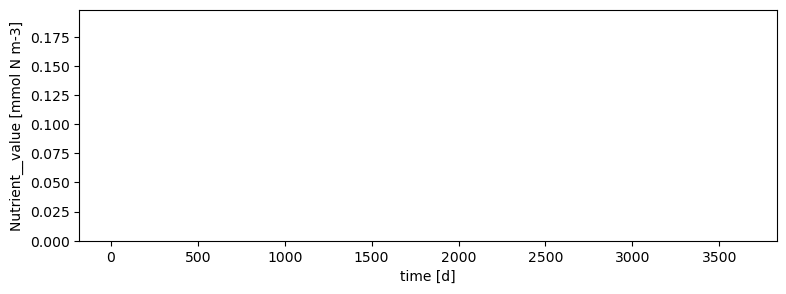

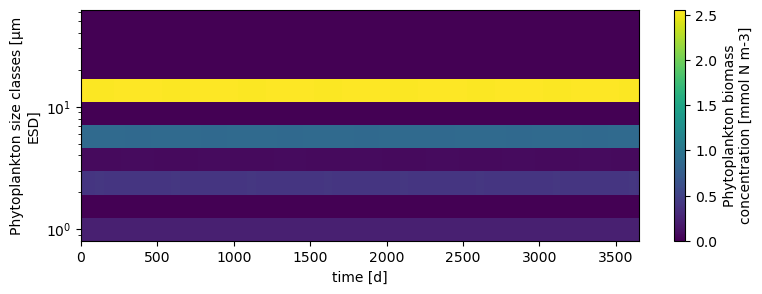

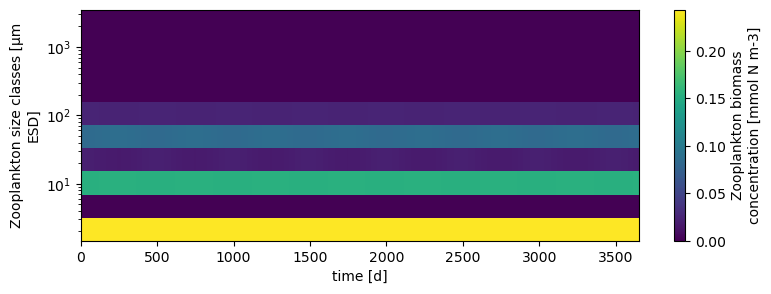

In [49]:
# let's get a quick overivew:

# plot nutrient:
model_out.Nutrient__value.plot(aspect=3, size=3, ylim=0)
# phytoplankton:
model_out.Phytoplankton__biomass.plot(yscale='log', aspect=3, size=3)
# zooplankton
model_out.Zooplankton__biomass.plot(yscale='log', aspect=3, size=3)

In [50]:
with NPxZxSizeBased:
        model_out_fsolve = model_setup_stability.xsimlab.update_vars(input_vars={'Nutrient__value_init':mean_out.Nutrient__value.values,
                                       'Phytoplankton__biomass_init':mean_out.Phytoplankton__biomass.values,
                                       'Zooplankton__biomass_init':mean_out.Zooplankton__biomass.values}
                                                             ).xsimlab.run()

[INFO] Initial state dimension: 21
[INFO] Initial state: [1.98156219e-001 2.29276525e-001 2.84930207e-092 3.96158535e-001
 6.77135070e-002 8.72899705e-001 4.69209542e-006 2.55199761e+000
 1.37473169e-015 1.37089276e-029 4.48060698e-035 2.43399782e-001
 8.45971730e-043 1.53148682e-001 2.13606377e-002 8.31674493e-002
 2.42774761e-002 1.82773625e-109 0.00000000e+000 0.00000000e+000
 0.00000000e+000]
[INFO] Steady state found with residual norm: 1.59e-12
  Steady state: [ 1.98163537e-001  2.29302510e-001  2.04581476e-100  3.95845831e-001
  6.83151423e-002  8.72563312e-001 -7.64419914e-011  2.55168799e+000
 -4.80139848e-025 -1.49102911e-039 -2.38924960e-045  2.43362271e-001
  6.85234997e-051  1.53980918e-001  1.91658194e-002  8.50988816e-002
  2.37442171e-002  5.52644290e-118  0.00000000e+000  0.00000000e+000
  0.00000000e+000]
[INFO] Computing Jacobian numerically...
[INFO] Successfully computed 21 eigenvalues


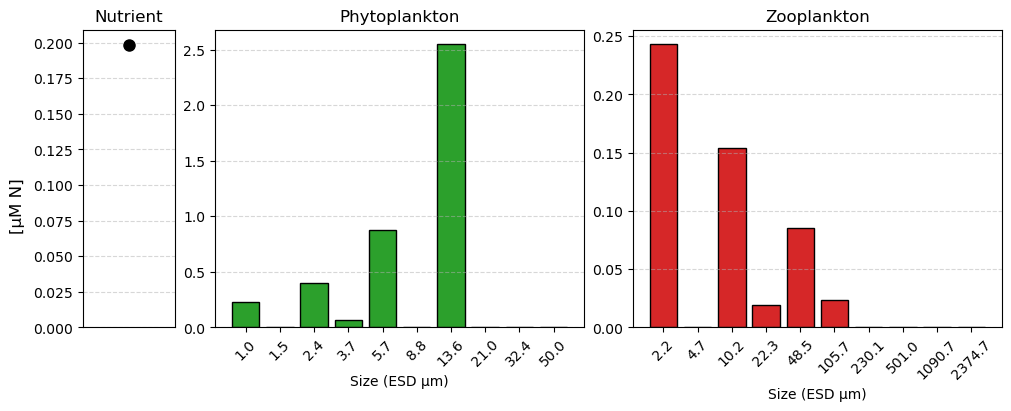

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Select the steady state (time=1)
ds_ss = model_out_fsolve.isel(time=-1)

# Create figure with 3 panels
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True, 
                         gridspec_kw={'width_ratios': [1, 4, 4]})

# Shared Y-axis label
fig.supylabel('[µM N]')

# --- 1. Nutrient (Dot) ---
axes[0].plot(0, ds_ss.Nutrient__value, 'o', color='k', markersize=8)
axes[0].set_title('Nutrient')
axes[0].set_ylim(bottom=0)
axes[0].set_xticks([])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- 2. Phytoplankton (Bar Plot) ---
x_phyto = np.arange(len(ds_ss.phyto))
axes[1].bar(x_phyto, ds_ss.Phytoplankton__biomass, color='tab:green', width=0.8, edgecolor='black')

axes[1].set_title('Phytoplankton')
axes[1].set_ylim(bottom=0)
axes[1].set_xticks(x_phyto)
axes[1].set_xticklabels([f"{x:.1f}" for x in ds_ss.phyto.values], rotation=45)
axes[1].set_xlabel('Size (ESD µm)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- 3. Zooplankton (Bar Plot) ---
x_zoo = np.arange(len(ds_ss.zoo))
axes[2].bar(x_zoo, ds_ss.Zooplankton__biomass, color='tab:red', width=0.8, edgecolor='black')

axes[2].set_title('Zooplankton')
axes[2].set_ylim(bottom=0)
axes[2].set_xticks(x_zoo)
axes[2].set_xticklabels([f"{x:.1f}" for x in ds_ss.zoo.values], rotation=45)
axes[2].set_xlabel('Size (ESD µm)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

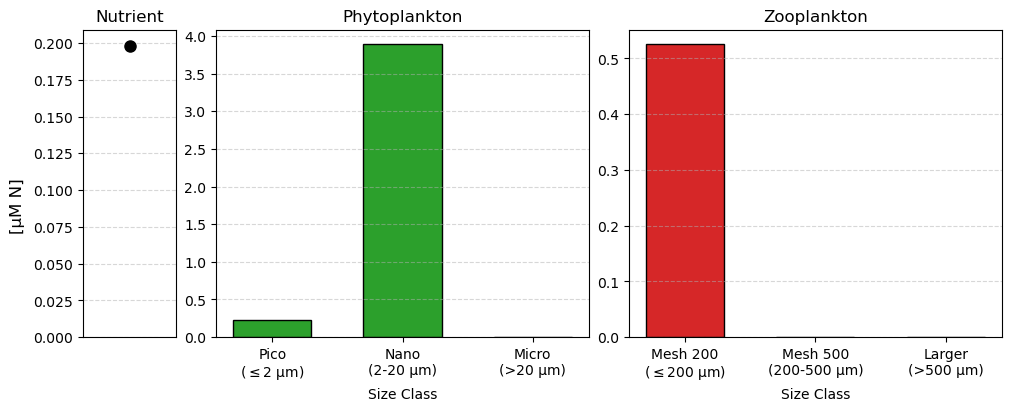

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select the steady state (time=1)
ds_ss = model_out_fsolve.isel(time=-1)

# 2. Binning Phytoplankton
phyto_pico = ds_ss.Phytoplankton__biomass.where(ds_ss.phyto <= 2, drop=True).sum().values
phyto_nano = ds_ss.Phytoplankton__biomass.where((ds_ss.phyto > 2) & (ds_ss.phyto <= 20), drop=True).sum().values
phyto_micro = ds_ss.Phytoplankton__biomass.where(ds_ss.phyto > 20, drop=True).sum().values

phyto_values = [phyto_pico, phyto_nano, phyto_micro]
# FIXED: Used \\leq instead of \le
phyto_labels = ['Pico\n($\\leq$2 µm)', 'Nano\n(2-20 µm)', 'Micro\n(>20 µm)']

# 3. Binning Zooplankton
zoo_200 = ds_ss.Zooplankton__biomass.where(ds_ss.zoo <= 200, drop=True).sum().values
zoo_500 = ds_ss.Zooplankton__biomass.where((ds_ss.zoo > 200) & (ds_ss.zoo <= 500), drop=True).sum().values
zoo_large = ds_ss.Zooplankton__biomass.where(ds_ss.zoo > 500, drop=True).sum().values

zoo_values = [zoo_200, zoo_500, zoo_large]
# FIXED: Used \\leq instead of \le
zoo_labels = ['Mesh 200\n($\\leq$200 µm)', 'Mesh 500\n(200-500 µm)', 'Larger\n(>500 µm)']

# 4. Plotting
fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True, 
                         gridspec_kw={'width_ratios': [1, 4, 4]})

fig.supylabel('[µM N]')

# --- Panel 1: Nutrient (Dot) ---
axes[0].plot(0, ds_ss.Nutrient__value, 'o', color='k', markersize=8)
axes[0].set_title('Nutrient')
axes[0].set_ylim(bottom=0)
axes[0].set_xticks([])
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Phytoplankton Bins ---
axes[1].bar(phyto_labels, phyto_values, color='tab:green', width=0.6, edgecolor='black')
axes[1].set_title('Phytoplankton')
axes[1].set_ylim(bottom=0)
axes[1].set_xlabel('Size Class')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 3: Zooplankton Bins ---
axes[2].bar(zoo_labels, zoo_values, color='tab:red', width=0.6, edgecolor='black')
axes[2].set_title('Zooplankton')
axes[2].set_ylim(bottom=0)
axes[2].set_xlabel('Size Class')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

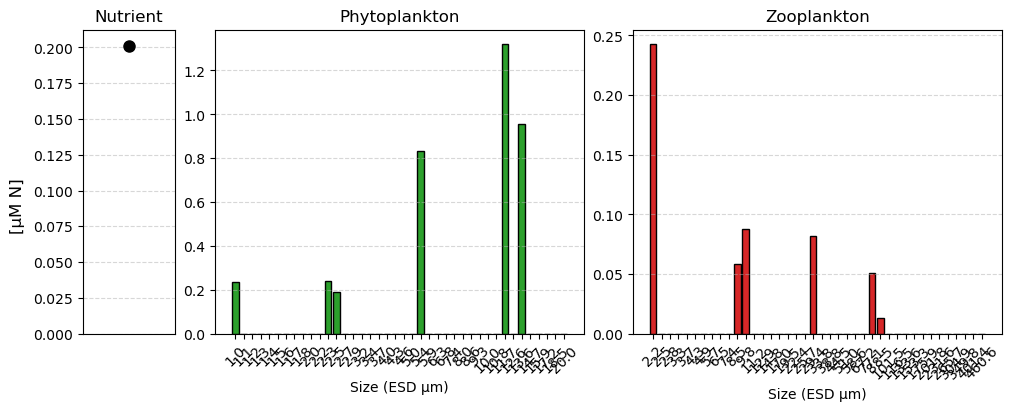

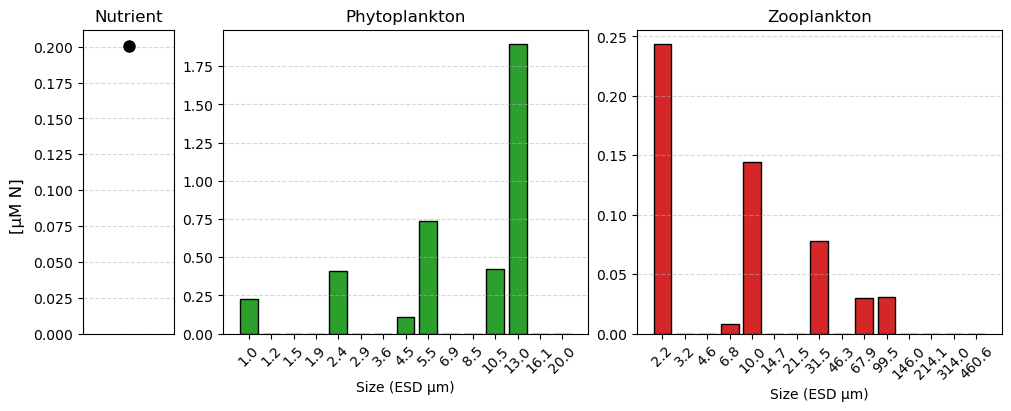

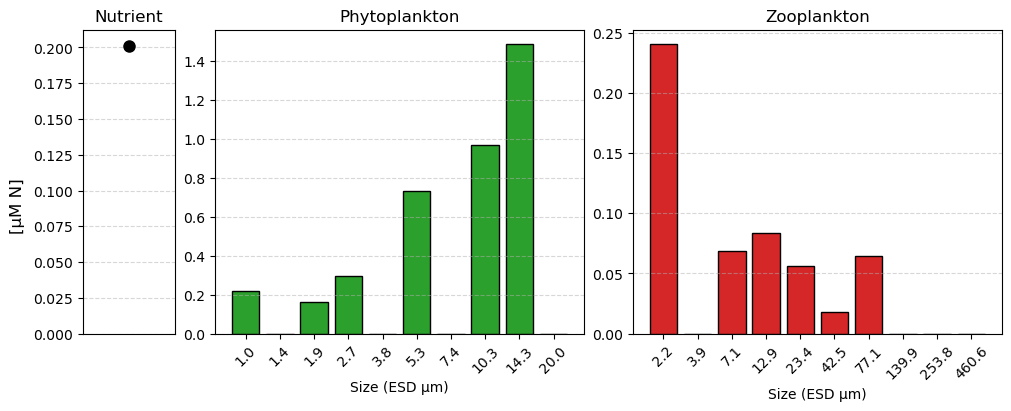